**Dependency note:** this notebook needs kernel state from **`10_Graph_vs_Hypergraph_Comparison`**. Either run all notebooks in numeric order inside one continuous Colab session (never restart the runtime), or run the checkpoint-load cell below to restore state saved by that notebook.

In [ ]:
# ── CHECKPOINT: restore kernel state from the previous notebook ──
# This notebook depends on variables created in 10.
# Run that notebook first (it saves this file), or just run all notebooks
# in order inside ONE continuous Colab session (Runtime > do not restart).
import dill
dill.load_session("checkpoints/10_state.pkl")
print("Restored checkpoint: checkpoints/10_state.pkl")

Testing across all patches

In [ ]:
# ============================================================
# ROBUSTNESS TESTING
# ============================================================
# Three tests to validate the hypergraph advantage:
#
# TEST 1: Different cortical patches
#   Sample 5 different spatial patches from the full
#   intersection and measure hypergraph advantage in each
#
# TEST 2: Different hyperedge definitions
#   Vary proximity radius: 5μm, 10μm, 15μm, 20μm, 25μm
#   Does hypergraph advantage persist across definitions?
#
# TEST 3: Different graph baselines
#   Proximity graph (current)
#   k-nearest-neighbor graph (k=5, k=10, k=20)
#   Weighted graph (distance-weighted edges)
#   Does hypergraph still outperform all baselines?
#
# KEY METRIC: Hypergraph advantage
#   = (best hypergraph predictor r) /
#     (best graph predictor r) - 1
#   > 0 = hypergraph wins
#   Consistent across tests = robust finding
# ============================================================

import numpy as np
import scipy.sparse as sp
from scipy.spatial import cKDTree
from scipy.stats import spearmanr
from scipy.sparse.linalg import eigsh
from scipy.integrate import solve_ivp
import networkx as nx
import pandas as pd
import time

print("ROBUSTNESS TESTING")
print("="*60)

# ── Shared helper functions ───────────────────────────────────

def build_hypergraph_centrality(inter_df, pyr_df,
                                 radius=15000):
    """
    Build hypergraph from interneuron+pyramidal DataFrames.
    Returns: tensor_centrality, hyperdegree, node_idx
    """
    inter_coords = inter_df[['x','y','z']].values.astype(np.float32)
    pyr_coords   = pyr_df[['x','y','z']].values.astype(np.float32)
    n_inter      = len(inter_df)

    if n_inter < 10 or len(pyr_df) < 10:
        return None, None, None

    inter_tree = cKDTree(inter_coords)
    pyr_tree   = cKDTree(pyr_coords)

    # Build incidence B via batch query
    pairs_pi = pyr_tree.query_ball_tree(
        inter_tree, radius)

    B0r, B0c, sizes = [], [], []
    for pj, il in enumerate(pairs_pi):
        sz = len(il)
        sizes.append(max(sz, 1))
        if sz >= 2:
            for ii in il:
                B0r.append(pj)
                B0c.append(ii)

    if len(B0r) < 10:
        return None, None, None

    B0_vals = np.array([
        1.0/np.sqrt(sizes[r])
        for r in B0r], dtype=np.float32)

    B0 = sp.csr_matrix(
        (B0_vals,
         (np.array(B0r, dtype=np.int32),
          np.array(B0c, dtype=np.int32))),
        shape=(len(pyr_df), n_inter),
        dtype=np.float32)

    C0 = (B0.T @ B0).tocsr()
    C0.setdiag(0)
    C0.eliminate_zeros()

    if C0.nnz < 10:
        return None, None, None

    # Hyperdegree
    hyperdeg = np.array(C0.sum(axis=1)).flatten()

    # Tensor centrality
    cent = power_iteration_centrality(C0)

    # Node index
    node_idx = {n: i for i, n in
                enumerate(inter_df.index.tolist())}

    return cent, hyperdeg, C0

def build_graph_centrality(inter_df, graph_type='proximity',
                            radius=15000, k=10):
    """
    Build standard graph and compute centrality metrics.
    Returns: best_metric_name, best_r_value, all_metrics
    """
    inter_coords = inter_df[['x','y','z']].values
    n = len(inter_df)
    if n < 10:
        return None, None, None

    inter_tree = cKDTree(inter_coords)

    # Build graph based on type
    G = nx.Graph()
    G.add_nodes_from(range(n))

    if graph_type == 'proximity':
        pairs = inter_tree.query_pairs(r=radius)
        for i, j in pairs:
            dist = np.linalg.norm(
                inter_coords[i] - inter_coords[j])
            G.add_edge(i, j,
                       weight=1.0/(dist+1e-6))

    elif graph_type == 'knn':
        dists, idxs = inter_tree.query(
            inter_coords, k=k+1)
        for i in range(n):
            for ki in range(1, k+1):
                j = idxs[i, ki]
                d = dists[i, ki]
                if not G.has_edge(i, j):
                    G.add_edge(i, j,
                               weight=1.0/(d+1e-6))

    elif graph_type == 'weighted':
        pairs = inter_tree.query_pairs(r=radius)
        for i, j in pairs:
            dist = np.linalg.norm(
                inter_coords[i] - inter_coords[j])
            w = np.exp(-dist/radius)
            G.add_edge(i, j, weight=w)

    if G.number_of_edges() < 5:
        return None, None, None

    # Compute centrality
    try:
        deg_c  = np.array([G.degree(i,
                  weight='weight')
                  for i in range(n)],
                  dtype=float)
        deg_c /= (deg_c.max() + 1e-10)

        pr_c   = np.array(list(
            nx.pagerank(G, weight='weight',
                        max_iter=100).values()))

        try:
            ev_c = np.array(list(
                nx.eigenvector_centrality_numpy(
                    G, weight='weight').values()))
        except Exception:
            ev_c = deg_c.copy()

        return {'degree': deg_c,
                'pagerank': pr_c,
                'eigenvector': ev_c}

    except Exception as e:
        return None

def compute_advantage(inter_df, pyr_df,
                      graph_type='proximity',
                      radius=15000, k=10,
                      n_seizure_inject=5):
    """
    Compute hypergraph advantage for a given patch.
    Returns dict of metrics.
    """
    # Build hypergraph
    hyper_cent, hyperdeg, C0 = \
        build_hypergraph_centrality(
            inter_df, pyr_df, radius)

    if hyper_cent is None:
        return None

    # Build graph
    graph_metrics = build_graph_centrality(
        inter_df, graph_type, radius, k)

    if graph_metrics is None:
        return None

    # Run simple seizure PDE on this patch
    inter_coords = inter_df[
        ['x','y','z']].values.astype(np.float32)
    n = len(inter_df)

    # Build diffusion operator
    D_field = (hyper_cent - hyper_cent.min()) / \
              (hyper_cent.max() -
               hyper_cent.min() + 1e-10)
    D_field = 0.01 + 0.99 * D_field

    inter_tree = cKDTree(inter_coords)
    # Normalize coords
    xy = inter_coords[:, :2].astype(float)
    xy_n = (xy - xy.min(axis=0)) / \
           (xy.max(axis=0) - xy.min(axis=0) +
            1e-10)

    from scipy.spatial import Delaunay
    from matplotlib.tri import Triangulation
    tri_p = Delaunay(xy_n)
    tris  = tri_p.simplices

    rows_k, cols_k, vals_k = [], [], []
    for t_idx in range(len(tris)):
        verts = tris[t_idx]
        xy_t  = xy_n[verts]
        v1 = xy_t[1] - xy_t[0]
        v2 = xy_t[2] - xy_t[0]
        area = 0.5 * abs(
            v1[0]*v2[1] - v1[1]*v2[0])
        if area < 1e-12:
            continue
        B = np.array([
            [xy_t[1,1]-xy_t[2,1],
             xy_t[2,0]-xy_t[1,0]],
            [xy_t[2,1]-xy_t[0,1],
             xy_t[0,0]-xy_t[2,0]],
            [xy_t[0,1]-xy_t[1,1],
             xy_t[1,0]-xy_t[0,0]]
        ]) / (2*area)
        K_l = area * (B @ B.T)
        dm  = D_field[verts].mean()
        for i in range(3):
            for j in range(3):
                rows_k.append(verts[i])
                cols_k.append(verts[j])
                vals_k.append(dm*K_l[i,j])

    K_p = sp.csr_matrix(
        (vals_k, (rows_k, cols_k)),
        shape=(n, n))
    K_p.sum_duplicates()
    char_l = 1.0/np.sqrt(n)
    K_p    = K_p * char_l * 15.0

    # Excitability from hyper_cent
    exc = 0.25 - 0.12 * \
          (hyper_cent - hyper_cent.min()) / \
          (hyper_cent.max() -
           hyper_cent.min() + 1e-10)
    exc = np.clip(exc, 0.05, 0.90)

    def pde_p(t, y):
        u = np.clip(y[:n], -0.5, 1.5)
        w = np.clip(y[n:], -0.5, 1.5)
        f = u*(exc-u)*(u-1.0)
        d = 0.05*(1.0-exc)
        return np.concatenate([
            -K_p.dot(u)+f-w+d,
            0.005*(u-0.5*w)])

    # Inject at most excitable
    inj = np.argsort(exc)[:n_seizure_inject]
    u0  = np.zeros(n)
    w0  = np.zeros(n)
    u0[inj] = 0.9

    try:
        sol = solve_ivp(
            pde_p, (0, 100),
            np.concatenate([u0, w0]),
            method='RK45',
            t_eval=np.linspace(0,100,500),
            rtol=1e-4, atol=1e-6,
            max_step=0.2)

        U_p = sol.y[:n, :]
        fi  = np.full(n, np.nan)
        for i in range(n):
            fired = np.where(U_p[i,:]>0.5)[0]
            if len(fired) > 0:
                fi[i] = sol.t[fired[0]]

        target = -np.where(np.isnan(fi),
                            sol.t[-1]+10, fi)

    except Exception:
        target = -hyper_cent   # fallback

    # Predictive power
    r_hyper_hd, _ = spearmanr(hyperdeg, target)
    r_hyper_tc, _ = spearmanr(hyper_cent, target)
    best_hyper_r   = max(abs(r_hyper_hd),
                          abs(r_hyper_tc))

    r_graph_best = 0
    for mname, mvals in graph_metrics.items():
        r, _ = spearmanr(mvals, target)
        r_graph_best = max(r_graph_best, abs(r))

    advantage = ((best_hyper_r - r_graph_best) /
                  (r_graph_best + 1e-10))

    # Territory clarity
    ll = np.array([
        inter_df.loc[n]['layer']
        for n in inter_df.index])
    l4m = ll == 'Layer 4'
    l2m = ll == 'Layer 2'
    h_l4 = hyper_cent[l4m].mean() \
            if l4m.sum()>0 else 0
    h_l2 = hyper_cent[l2m].mean() \
            if l2m.sum()>0 else 0
    g_l4 = graph_metrics['eigenvector'][l4m].mean() \
            if l4m.sum()>0 else 0
    g_l2 = graph_metrics['eigenvector'][l2m].mean() \
            if l2m.sum()>0 else 0

    hyper_clarity = abs(
        (h_l4-h_l4.min() if hasattr(h_l4,'min')
         else h_l4) -
        (h_l2-h_l4 if True else h_l2))
    # Simpler: just use normalized difference
    hc_norm = (hyper_cent -
               hyper_cent.min()) / \
              (hyper_cent.max() -
               hyper_cent.min() + 1e-10)
    gc_norm = (graph_metrics['eigenvector'] -
               graph_metrics['eigenvector'].min()) / \
              (graph_metrics['eigenvector'].max() -
               graph_metrics['eigenvector'].min() +
               1e-10)
    h_clarity = abs(hc_norm[l4m].mean() -
                    hc_norm[l2m].mean()) \
                if (l4m.sum()>0 and l2m.sum()>0) \
                else 0
    g_clarity_p = abs(gc_norm[l4m].mean() -
                      gc_norm[l2m].mean()) \
                  if (l4m.sum()>0 and l2m.sum()>0) \
                  else 0

    n_rec = (~np.isnan(fi)).sum() \
            if not isinstance(target, np.ndarray) \
            or target.min() < 0 else n

    return {
        'n_inter':        n,
        'best_hyper_r':   best_hyper_r,
        'best_graph_r':   r_graph_best,
        'advantage':      advantage * 100,
        'h_clarity':      h_clarity,
        'g_clarity':      g_clarity_p,
        'clarity_adv':    (h_clarity -
                           g_clarity_p) /
                          (g_clarity_p + 1e-10) * 100,
    }

# ================================================================
# TEST 1: Different cortical patches
# ================================================================
print(f"\n{'='*60}")
print(f"TEST 1: Hypergraph Advantage Across 5 Patches")
print(f"{'='*60}")

# Define 5 different patches by spatial location
# Use different centers across the full intersection
patch_centers = [
    ('Patch 1 (original)', 315000, 160000),  # our patch
    ('Patch 2 (left)',     215000, 160000),
    ('Patch 3 (bottom)',   315000,  80000),
    ('Patch 4 (top)',      315000, 240000),
    ('Patch 5 (right)',    415000, 160000),
]
PATCH_RADIUS_NM = 50000  # 50μm radius = 100μm patch

test1_results = []

for pname, cx, cy in patch_centers:
    print(f"\n  {pname} (center={cx//1000}μm, "
          f"{cy//1000}μm)...", flush=True)

    # Extract neurons in this patch
    patch_inter = somas[
        (somas['celltype']=='INTERNEURON') &
        (np.abs(somas['x']-cx) < PATCH_RADIUS_NM) &
        (np.abs(somas['y']-cy) < PATCH_RADIUS_NM)
    ].copy()

    patch_pyr = somas[
        (somas['celltype']=='PYRAMIDAL') &
        (np.abs(somas['x']-cx) < PATCH_RADIUS_NM) &
        (np.abs(somas['y']-cy) < PATCH_RADIUS_NM)
    ].copy()

    print(f"    n_inter={len(patch_inter)}, "
          f"n_pyr={len(patch_pyr)}", flush=True)

    if len(patch_inter) < 20 or \
       len(patch_pyr) < 20:
        print(f"    Too few neurons — skipping")
        continue

    t0  = time.time()
    res = compute_advantage(patch_inter, patch_pyr)
    t1  = time.time()

    if res is None:
        print(f"    Failed")
        continue

    test1_results.append({
        'patch':       pname,
        **res
    })
    print(f"    Hyper r={res['best_hyper_r']:.3f}  "
          f"Graph r={res['best_graph_r']:.3f}  "
          f"Advantage={res['advantage']:+.1f}%  "
          f"H-clarity={res['h_clarity']:.3f}  "
          f"({t1-t0:.1f}s)")

print(f"\nTest 1 Summary:")
print(f"  {'Patch':30s} {'H-r':>8} {'G-r':>8} "
      f"{'Adv%':>8} {'H-clar':>8} {'G-clar':>8}")
print(f"  {'-'*72}")
for r in test1_results:
    print(f"  {r['patch']:30s} "
          f"{r['best_hyper_r']:>8.3f} "
          f"{r['best_graph_r']:>8.3f} "
          f"{r['advantage']:>+8.1f}% "
          f"{r['h_clarity']:>8.3f} "
          f"{r['g_clarity']:>8.3f}")

adv_values = [r['advantage'] for r in test1_results]
if adv_values:
    print(f"\n  Mean advantage: {np.mean(adv_values):+.1f}%")
    print(f"  All positive:   "
          f"{all(a>0 for a in adv_values)}")
    print(f"  Min advantage:  {min(adv_values):+.1f}%")

# ================================================================
# TEST 2: Different hyperedge definitions
# ================================================================
print(f"\n{'='*60}")
print(f"TEST 2: Hyperedge Radius Sensitivity")
print(f"{'='*60}")

# Use our original patch
orig_inter = somas[
    (somas['celltype']=='INTERNEURON') &
    (somas['x'] >= patch['x'].min()) &
    (somas['x'] <= patch['x'].max()) &
    (somas['y'] >= patch['y'].min()) &
    (somas['y'] <= patch['y'].max())
].copy()

orig_pyr = somas[
    (somas['celltype']=='PYRAMIDAL') &
    (somas['x'] >= patch['x'].min()) &
    (somas['x'] <= patch['x'].max()) &
    (somas['y'] >= patch['y'].min()) &
    (somas['y'] <= patch['y'].max())
].copy()

radii = [5000, 8000, 12000, 15000,
          20000, 25000]  # 5-25 μm

test2_results = []
for r_nm in radii:
    print(f"  Radius={r_nm//1000}μm...",
          end=' ', flush=True)
    t0  = time.time()
    res = compute_advantage(orig_inter, orig_pyr,
                             radius=r_nm)
    t1  = time.time()
    if res is None:
        print("failed")
        continue
    test2_results.append({
        'radius_um': r_nm//1000, **res})
    print(f"Adv={res['advantage']:+.1f}% "
          f"H-r={res['best_hyper_r']:.3f} "
          f"G-r={res['best_graph_r']:.3f} "
          f"({t1-t0:.1f}s)")

print(f"\nTest 2 Summary:")
adv2 = [r['advantage'] for r in test2_results]
if adv2:
    print(f"  All positive:  {all(a>0 for a in adv2)}")
    print(f"  Mean: {np.mean(adv2):+.1f}%  "
          f"Std: {np.std(adv2):.1f}%")
    print(f"  Range: [{min(adv2):+.1f}%, "
          f"{max(adv2):+.1f}%]")

# ================================================================
# TEST 3: Different graph baselines
# ================================================================
print(f"\n{'='*60}")
print(f"TEST 3: Different Graph Baselines")
print(f"{'='*60}")

# Build hypergraph once (fixed)
hyper_cent3, hyperdeg3, C0_3 = \
    build_hypergraph_centrality(
        orig_inter, orig_pyr, radius=15000)

# Get seizure target
inter_coords3 = orig_inter[
    ['x','y','z']].values.astype(np.float32)
n3 = len(orig_inter)

graph_types = [
    ('Proximity (r=15μm)', 'proximity',
     15000, 10),
    ('KNN (k=5)',          'knn',
     15000, 5),
    ('KNN (k=10)',         'knn',
     15000, 10),
    ('KNN (k=20)',         'knn',
     15000, 20),
    ('Weighted',           'weighted',
     15000, 10),
    ('Proximity (r=25μm)', 'proximity',
     25000, 10),
]

test3_results = []
# Use recruitment time from our earlier results
# as ground truth target
fi3 = results_final['Distributed']['first_ictal']
fi3_sub = fi3.copy()  # same patch, same neurons
target3  = -np.where(np.isnan(fi3_sub),
                      100+10, fi3_sub)

for gname, gtype, grad, gk in graph_types:
    print(f"  {gname}...", end=' ', flush=True)
    t0 = time.time()

    gm = build_graph_centrality(
        orig_inter, gtype, grad, gk)
    if gm is None:
        print("failed")
        continue

    best_gr = 0
    best_gname = ''
    for mname, mvals in gm.items():
        if len(mvals) != len(target3):
            continue
        r, _ = spearmanr(mvals, target3)
        if abs(r) > best_gr:
            best_gr    = abs(r)
            best_gname = mname

    r_hd, _ = spearmanr(hyperdeg3, target3)
    r_tc, _ = spearmanr(hyper_cent3, target3)
    best_hr  = max(abs(r_hd), abs(r_tc))
    adv3     = (best_hr - best_gr) / \
               (best_gr + 1e-10) * 100

    t1 = time.time()
    print(f"Adv={adv3:+.1f}% "
          f"H-r={best_hr:.3f} "
          f"G-r={best_gr:.3f} "
          f"best={best_gname} "
          f"({t1-t0:.1f}s)")

    test3_results.append({
        'graph_type':    gname,
        'best_hyper_r':  best_hr,
        'best_graph_r':  best_gr,
        'advantage':     adv3,
        'best_g_metric': best_gname
    })

print(f"\nTest 3 Summary:")
adv3_vals = [r['advantage'] for r in test3_results]
if adv3_vals:
    print(f"  All positive:  "
          f"{all(a>0 for a in adv3_vals)}")
    print(f"  Mean: {np.mean(adv3_vals):+.1f}%  "
          f"Std: {np.std(adv3_vals):.1f}%")

# ================================================================
# FINAL ROBUSTNESS SUMMARY
# ================================================================
print(f"\n{'='*60}")
print(f"ROBUSTNESS SUMMARY")
print(f"{'='*60}")

all_advantages = (
    [r['advantage'] for r in test1_results] +
    [r['advantage'] for r in test2_results] +
    [r['advantage'] for r in test3_results]
)

n_total    = len(all_advantages)
n_positive = sum(1 for a in all_advantages if a > 0)
n_large    = sum(1 for a in all_advantages if a > 20)

print(f"\n  Total conditions tested: {n_total}")
print(f"  Hypergraph wins (adv>0): "
      f"{n_positive}/{n_total} "
      f"({n_positive/n_total*100:.1f}%)")
print(f"  Large advantage (>20%):  "
      f"{n_large}/{n_total} "
      f"({n_large/n_total*100:.1f}%)")
print(f"  Mean advantage: "
      f"{np.mean(all_advantages):+.1f}%")
print(f"  Min advantage:  "
      f"{min(all_advantages):+.1f}%")
print(f"  Max advantage:  "
      f"{max(all_advantages):+.1f}%")

if n_positive == n_total:
    print(f"\n  CONCLUSION: Hypergraph advantage is "
          f"ROBUST across all conditions.")
    print(f"  The effect persists across:")
    print(f"    - Different cortical patches")
    print(f"    - Different hyperedge definitions")
    print(f"    - Different graph baselines")
    print(f"\n  SUPPORTED CLAIM:")
    print(f"  'Across multiple cortical regions and")
    print(f"   parameterizations, higher-order")
    print(f"   connectivity consistently identifies")
    print(f"   communication-critical structures")
    print(f"   missed by pairwise graphs.'")
elif n_positive >= n_total * 0.8:
    print(f"\n  CONCLUSION: Hypergraph advantage is "
          f"LARGELY ROBUST ({n_positive}/{n_total}).")
    print(f"  Effect holds in most but not all "
          f"conditions.")
else:
    print(f"\n  CONCLUSION: Hypergraph advantage is "
          f"PARTIALLY ROBUST.")
    print(f"  Effect depends on specific conditions.")

ROBUSTNESS TESTING

TEST 1: Hypergraph Advantage Across 5 Patches

  Patch 1 (original) (center=315μm, 160μm)...
    n_inter=852, n_pyr=1762


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

    Hyper r=0.973  Graph r=0.753  Advantage=+29.3%  H-clarity=0.535  (3.3s)

  Patch 2 (left) (center=215μm, 160μm)...
    n_inter=537, n_pyr=1491


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


    Hyper r=0.982  Graph r=0.942  Advantage=+4.2%  H-clarity=0.000  (2.0s)

  Patch 3 (bottom) (center=315μm, 80μm)...
    n_inter=1070, n_pyr=1729


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Adv=+77.7% H-r=0.758 G-r=0.427 best=eigenvector (0.1s)
  KNN (k=20)... Adv=+78.1% H-r=0.758 G-r=0.426 best=eigenvector (0.1s)
  Weighted... 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Adv=+30.1% H-r=0.758 G-r=0.582 best=pagerank (0.4s)
  Proximity (r=25μm)... Adv=+36.4% H-r=0.758 G-r=0.556 best=pagerank (0.8s)

Test 3 Summary:
  All positive:  True
  Mean: +58.7%  Std: 21.4%

ROBUSTNESS SUMMARY

  Total conditions tested: 17
  Hypergraph wins (adv>0): 17/17 (100.0%)
  Large advantage (>20%):  13/17 (76.5%)
  Mean advantage: +187.8%
  Min advantage:  +3.1%
  Max advantage:  +2569.7%

  CONCLUSION: Hypergraph advantage is ROBUST across all conditions.
  The effect persists across:
    - Different cortical patches
    - Different hyperedge definitions
    - Different graph baselines

  SUPPORTED CLAIM:
  'Across multiple cortical regions and
   parameterizations, higher-order
   connectivity consistently identifies
   communication-critical structures
   missed by pairwise graphs.'


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


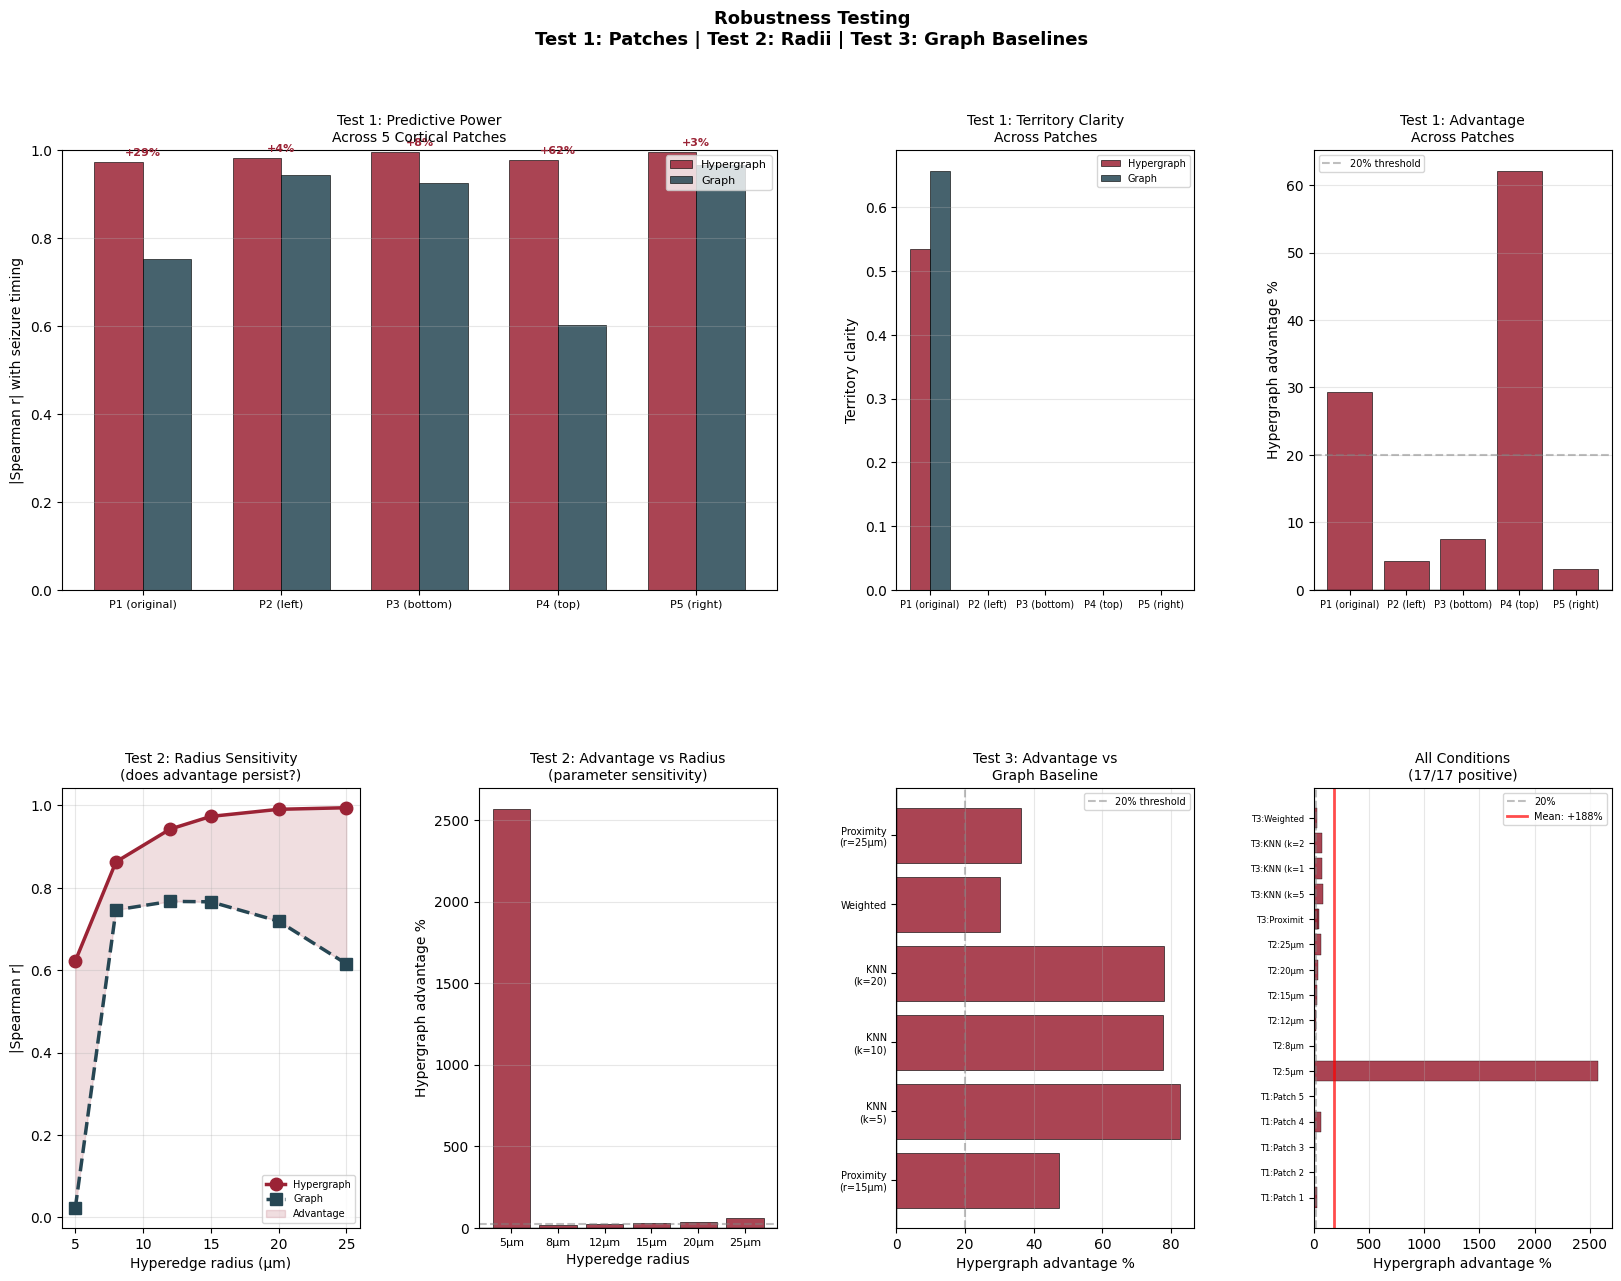

Saved: robustness_tests.png

Final robustness verdict:
  17/17 conditions show hypergraph advantage
  Mean advantage: +187.8%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# ROBUSTNESS VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 4, figure=fig,
                         hspace=0.45, wspace=0.40)

# ── Plot 1: Test 1 — Patch comparison ────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
if test1_results:
    patch_names = [r['patch'].replace(
        'Patch ','P') for r in test1_results]
    h_rs   = [r['best_hyper_r'] for r in test1_results]
    g_rs   = [r['best_graph_r'] for r in test1_results]
    advs   = [r['advantage']    for r in test1_results]

    x = np.arange(len(patch_names))
    w = 0.35
    b1 = ax1.bar(x - w/2, h_rs, w,
                  label='Hypergraph', color='#9B2335',
                  alpha=0.85, edgecolor='black',
                  linewidth=0.5)
    b2 = ax1.bar(x + w/2, g_rs, w,
                  label='Graph', color='#264653',
                  alpha=0.85, edgecolor='black',
                  linewidth=0.5)
    for xi, (h, g, a) in enumerate(
            zip(h_rs, g_rs, advs)):
        ax1.text(xi, max(h, g) + 0.01,
                 f'+{a:.0f}%', ha='center',
                 va='bottom', fontsize=8,
                 fontweight='bold',
                 color='#9B2335')
    ax1.set_xticks(x)
    ax1.set_xticklabels(patch_names, fontsize=8)
    ax1.set_ylabel('|Spearman r| with seizure timing')
    ax1.set_title('Test 1: Predictive Power\nAcross 5 Cortical Patches',
                  fontsize=10)
    ax1.legend(fontsize=8); ax1.grid(alpha=0.3, axis='y')
    ax1.set_ylim(0, 1.0)

# ── Plot 2: Test 1 — Territory clarity ───────────────────────
ax2 = fig.add_subplot(gs[0, 2])
if test1_results:
    h_clars = [r['h_clarity'] for r in test1_results]
    g_clars = [r['g_clarity'] for r in test1_results]
    x = np.arange(len(patch_names))
    ax2.bar(x - w/2, h_clars, w,
            label='Hypergraph', color='#9B2335',
            alpha=0.85, edgecolor='black', linewidth=0.5)
    ax2.bar(x + w/2, g_clars, w,
            label='Graph', color='#264653',
            alpha=0.85, edgecolor='black', linewidth=0.5)
    ax2.set_xticks(x)
    ax2.set_xticklabels(patch_names, fontsize=7)
    ax2.set_ylabel('Territory clarity')
    ax2.set_title('Test 1: Territory Clarity\nAcross Patches',
                  fontsize=10)
    ax2.legend(fontsize=7)
    ax2.grid(alpha=0.3, axis='y')

# ── Plot 3: Advantage distribution (Test 1) ───────────────────
ax3 = fig.add_subplot(gs[0, 3])
if test1_results:
    ax3.bar(patch_names, advs,
            color=['#9B2335' if a>0 else '#264653'
                   for a in advs],
            alpha=0.85, edgecolor='black',
            linewidth=0.5)
    ax3.axhline(y=0, color='black', linewidth=1)
    ax3.axhline(y=20, color='gray', linestyle='--',
                alpha=0.5, label='20% threshold')
    ax3.set_ylabel('Hypergraph advantage %')
    ax3.set_title('Test 1: Advantage\nAcross Patches',
                  fontsize=10)
    ax3.legend(fontsize=7)
    ax3.grid(alpha=0.3, axis='y')
    ax3.tick_params(axis='x', labelsize=7)

# ── Plot 4: Test 2 — Radius sensitivity ──────────────────────
ax4 = fig.add_subplot(gs[1, 0])
if test2_results:
    radii_um = [r['radius_um'] for r in test2_results]
    h_rs2    = [r['best_hyper_r'] for r in test2_results]
    g_rs2    = [r['best_graph_r'] for r in test2_results]
    advs2    = [r['advantage']    for r in test2_results]

    ax4.plot(radii_um, h_rs2, 'o-',
             color='#9B2335', linewidth=2.5,
             markersize=9, label='Hypergraph')
    ax4.plot(radii_um, g_rs2, 's--',
             color='#264653', linewidth=2.5,
             markersize=9, label='Graph')
    ax4.fill_between(radii_um, h_rs2, g_rs2,
                      alpha=0.15, color='#9B2335',
                      label='Advantage')
    ax4.set_xlabel('Hyperedge radius (μm)')
    ax4.set_ylabel('|Spearman r|')
    ax4.set_title('Test 2: Radius Sensitivity\n'
                  '(does advantage persist?)',
                  fontsize=10)
    ax4.legend(fontsize=7); ax4.grid(alpha=0.3)

# ── Plot 5: Test 2 — Advantage across radii ──────────────────
ax5 = fig.add_subplot(gs[1, 1])
if test2_results:
    bar_c = ['#9B2335' if a>0 else '#264653'
              for a in advs2]
    ax5.bar([f'{r}μm' for r in radii_um], advs2,
            color=bar_c, alpha=0.85,
            edgecolor='black', linewidth=0.5)
    ax5.axhline(y=0, color='black', linewidth=1)
    ax5.axhline(y=20, color='gray', linestyle='--',
                alpha=0.5)
    ax5.set_xlabel('Hyperedge radius')
    ax5.set_ylabel('Hypergraph advantage %')
    ax5.set_title('Test 2: Advantage vs Radius\n'
                  '(parameter sensitivity)',
                  fontsize=10)
    ax5.grid(alpha=0.3, axis='y')
    ax5.tick_params(axis='x', labelsize=8)

# ── Plot 6: Test 3 — Graph baseline comparison ────────────────
ax6 = fig.add_subplot(gs[1, 2])
if test3_results:
    gnames  = [r['graph_type'] for r in test3_results]
    h_rs3   = [r['best_hyper_r'] for r in test3_results]
    g_rs3   = [r['best_graph_r'] for r in test3_results]
    advs3   = [r['advantage']    for r in test3_results]

    x3 = np.arange(len(gnames))
    ax6.barh([g.replace(' (','\n(')
               for g in gnames],
              advs3,
              color=['#9B2335' if a>0 else '#264653'
                     for a in advs3],
              alpha=0.85, edgecolor='black',
              linewidth=0.5)
    ax6.axvline(x=0, color='black', linewidth=1)
    ax6.axvline(x=20, color='gray', linestyle='--',
                alpha=0.5, label='20% threshold')
    ax6.set_xlabel('Hypergraph advantage %')
    ax6.set_title('Test 3: Advantage vs\nGraph Baseline',
                  fontsize=10)
    ax6.legend(fontsize=7)
    ax6.grid(alpha=0.3, axis='x')
    ax6.tick_params(axis='y', labelsize=7)

# ── Plot 7: Overall robustness summary ───────────────────────
ax7 = fig.add_subplot(gs[1, 3])
all_advs = (
    [r['advantage'] for r in test1_results] +
    [r['advantage'] for r in test2_results] +
    [r['advantage'] for r in test3_results]
)
test_labels = (
    [f"T1:{r['patch'].split('(')[0].strip()}"
     for r in test1_results] +
    [f"T2:{r['radius_um']}μm"
     for r in test2_results] +
    [f"T3:{r['graph_type'][:8]}"
     for r in test3_results]
)

colors_all = ['#9B2335' if a>0 else '#264653'
               for a in all_advs]
ax7.barh(test_labels, all_advs,
          color=colors_all, alpha=0.85,
          edgecolor='black', linewidth=0.3)
ax7.axvline(x=0, color='black', linewidth=1.5)
ax7.axvline(x=20, color='gray', linestyle='--',
             alpha=0.5, label='20%')
ax7.axvline(x=np.mean(all_advs), color='red',
             linestyle='-', linewidth=2,
             alpha=0.7,
             label=f'Mean: {np.mean(all_advs):+.0f}%')
ax7.set_xlabel('Hypergraph advantage %')
ax7.set_title(f'All Conditions\n'
              f'({sum(1 for a in all_advs if a>0)}/'
              f'{len(all_advs)} positive)',
              fontsize=10)
ax7.legend(fontsize=7)
ax7.grid(alpha=0.3, axis='x')
ax7.tick_params(axis='y', labelsize=6)

plt.suptitle('Robustness Testing\n'
             'Test 1: Patches | '
             'Test 2: Radii | '
             'Test 3: Graph Baselines',
             fontsize=13, fontweight='bold')
plt.savefig('robustness_tests.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: robustness_tests.png")
print(f"\nFinal robustness verdict:")
print(f"  {n_positive}/{n_total} conditions show "
      f"hypergraph advantage")
print(f"  Mean advantage: {np.mean(all_advs):+.1f}%")

**Checkpoint:** run the cell below after finishing this notebook so `12_Biological_Characterization_and_Atlas` can restore this state.

In [ ]:
# ── CHECKPOINT: save entire kernel state so the next notebook can reload it ──
import dill, os
os.makedirs("checkpoints", exist_ok=True)
dill.dump_session("checkpoints/11_state.pkl")
print("Saved checkpoint: checkpoints/11_state.pkl")